In [183]:
# Setup: Add parent directory to Python path to import beaversim modules# Apply Gaussian blur to all images (increase/decrease sigma for stronger/weaker smoothing)
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
for parent in [cwd, *cwd.parents]:
    if (parent / 'beaversim').is_dir():
        project_root = parent
        break
else:
    raise RuntimeError("Could not locate project root containing 'beaversim'.")

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Project root: {project_root}")
print(f"Python path updated to include: {project_root}")

Project root: /home/fedeoli/Documents/Projects/BeaverSim
Python path updated to include: /home/fedeoli/Documents/Projects/BeaverSim


In [184]:
import numpy as np
from pathlib import Path
from beaversim.ral.backend.beavers_visualizer_backend import BeaversVisualizerBackend

# Define one or more Monte Carlo result folders to compare
base_dirs = [    

    ### Lmax and stigmergy analysis
    # explorers - quality - Lmax 100 - Lmax 1000 - beta_repulsive 0.2
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_quality_eta_1_perc_explorer_rep_quality_02").resolve(),
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_quality_eta_1_perc_explorer_rep_quality_02").resolve(),

    # explorers - visits - Lmax 100 - Lmax 1000 - beta_repulsive 0.2
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_1_perc_explorer_rep_quality_02").resolve(),
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_visits_eta_1_perc_explorer_rep_quality_02").resolve(),

    # explorers - quality - Lmax 100 - Lmax 1000 - beta_repulsive 0.8
    Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_quality_eta_1_perc_explorer_rep_quality_08").resolve(),
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_quality_eta_1_perc_explorer_rep_quality_08").resolve(),        
    
    # explorers - visits - Lmax 100 - Lmax 1000 - beta_repulsive 0.8
    Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_1_perc_explorer_rep_quality_08").resolve(),
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_visits_eta_1_perc_explorer_rep_quality_08").resolve(),

    # builders - quality - Lmax 100 - Lmax 1000 - beta_repulsive 0.2
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_quality_eta_1_perc_builder_rep_quality_02").resolve(),
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_quality_eta_1_perc_builder_rep_quality_02").resolve(),

    # builders - visits - Lmax 100 - Lmax 1000 - beta_repulsive 0.2
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_1_perc_builder_rep_quality_02").resolve(),
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_visits_eta_1_perc_builder_rep_quality_02").resolve(),

    # builders - quality - Lmax 100 - Lmax 1000 - beta_repulsive 0.8
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_quality_eta_1_perc_builder_rep_quality_08").resolve(),
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_quality_eta_1_perc_builder_rep_quality_08").resolve(),

    # builders - visits - Lmax 100 - Lmax 1000 - beta_repulsive 0.8
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_1_perc_builder_rep_quality_08").resolve(),    
    # Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_1000_visits_eta_1_perc_builder_rep_quality_08").resolve(),

    ### ETA analysis
    # explorers - visits - Lmax 100 - Lmax 1000 - beta_repulsive 0.8 - eta 0.9
    Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_090_perc_explorer_rep_quality_08").resolve(),
    Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_095_perc_explorer_rep_quality_08").resolve(),
    Path("../../output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_099_perc_explorer_rep_quality_08").resolve(),
    
    
]

backend_file = "final_backend.pkl.gz"
series_order = [
    ("water_pixel_density", "Water Pixel Density"),
    ("builder_trail_pixel_density", "Builder Trail Density"),
    ("explorer_trail_pixel_density", "Explorer Trail Density"),
]

sim_results = {}

for base_dir in base_dirs:
    montecarlo_dir = base_dir / "montecarlo"

    if not montecarlo_dir.exists():
        print(f"⚠ Monte Carlo directory not found: {montecarlo_dir.resolve()}")
        continue

    seed_dirs = sorted([d for d in montecarlo_dir.iterdir() if d.is_dir() and d.name.startswith("seed_")])
    if not seed_dirs:
        print(f"⚠ No seed directories found in {montecarlo_dir}")
        continue

    print(f"\nLoading simulation: {base_dir.name}")
    print(f"Found {len(seed_dirs)} seed directories in: {montecarlo_dir}")

    all_stats = {}
    for seed_dir in seed_dirs:
        backend_path = seed_dir / backend_file
        if not backend_path.exists():
            print(f"⚠ Warning: {backend_file} not found in {seed_dir.name}, skipping...")
            continue

        try:
            back = BeaversVisualizerBackend.load_backend_pickle(str(backend_path))
            stats = getattr(back._environment, "_plotting_stats", None)
            if not stats:
                print(f"⚠ Warning: No plotting stats in {seed_dir.name}, skipping...")
                continue

            for key, values in stats.items():
                all_stats.setdefault(key, []).append(np.asarray(values, dtype=float))

            print(f"✓ Loaded stats from {seed_dir.name}")
        except Exception as e:
            print(f"⚠ Error loading {seed_dir.name}: {e}")
            continue

    if not all_stats:
        print(f"⚠ No stats collected from {base_dir.name}, skipping...")
        continue

    sim_results[base_dir.name] = {
        "base_dir": base_dir,
        "seed_dirs": seed_dirs,
        "all_stats": all_stats,
    }

print(f"\nLoaded {len(sim_results)} simulation(s) for comparison.")


Loading simulation: REV_10_agents_6_months_Lmax_100_quality_eta_1_perc_explorer_rep_quality_08
Found 5 seed directories in: /home/fedeoli/Documents/Projects/BeaverSim/output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_quality_eta_1_perc_explorer_rep_quality_08/montecarlo
✓ Loaded stats from seed_1
✓ Loaded stats from seed_2
✓ Loaded stats from seed_3
✓ Loaded stats from seed_4
✓ Loaded stats from seed_5

Loading simulation: REV_10_agents_6_months_Lmax_100_visits_eta_1_perc_explorer_rep_quality_08
Found 5 seed directories in: /home/fedeoli/Documents/Projects/BeaverSim/output/simulations/rumney_ranch_demo/REV_10_agents_6_months_Lmax_100_visits_eta_1_perc_explorer_rep_quality_08/montecarlo
✓ Loaded stats from seed_1
✓ Loaded stats from seed_2
✓ Loaded stats from seed_3
✓ Loaded stats from seed_4
✓ Loaded stats from seed_5

Loading simulation: REV_10_agents_6_months_Lmax_100_visits_eta_090_perc_explorer_rep_quality_08
Found 5 seed directories in: /home/fedeoli/Documents/

In [185]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Load all backends from seed directories and aggregate stats
# ============================================================================
backend_file = "final_backend.pkl.gz"
all_stats = {}  # key -> list of arrays (one per seed)

for seed_dir in seed_dirs:
    backend_path = seed_dir / backend_file
    if not backend_path.exists():
        print(f"⚠ Warning: {backend_file} not found in {seed_dir.name}, skipping...")
        continue
    
    # Load backend
    try:
        back = BeaversVisualizerBackend.load_backend_pickle(str(backend_path))
        stats = getattr(back._environment, '_plotting_stats', None)
        if not stats:
            print(f"⚠ Warning: No plotting stats in {seed_dir.name}, skipping...")
            continue
        
        # Store stats for this seed
        for key, values in stats.items():
            if key not in all_stats:
                all_stats[key] = []
            all_stats[key].append(np.asarray(values, dtype=float))
        
        print(f"✓ Loaded stats from {seed_dir.name}")
    except Exception as e:
        print(f"⚠ Error loading {seed_dir.name}: {e}")
        continue

if not all_stats:
    raise ValueError("No stats collected from any seed directories.")

# ============================================================================
# Compute mean and std across seeds (time-dependent)
# ============================================================================
series_order = [
    ('water_pixel_density', 'Water Pixel Density'),
    ('builder_trail_pixel_density', 'Builder Trail Density'),
    ('explorer_trail_pixel_density', 'Explorer Trail Density'),
]

# Get max length
max_len = max([len(arr) for arrays in all_stats.values() for arr in arrays] + [0])
print(f"\nMax time steps across all runs: {max_len}")

# Pad and stack arrays
aggregated = {}
for key, title in series_order:
    if key not in all_stats or not all_stats[key]:
        continue
    
    arrays = all_stats[key]
    # Pad arrays with NaN to the same length
    padded = np.full((len(arrays), max_len), np.nan, dtype=float)
    for i, arr in enumerate(arrays):
        padded[i, :len(arr)] = arr
    
    # Compute mean and std (ignoring NaN)
    mean_vals = np.nanmean(padded, axis=0)
    std_vals = np.nanstd(padded, axis=0)
    
    aggregated[key] = {
        'mean': mean_vals,
        'std': std_vals,
        'n_seeds': len(arrays),
    }

print(f"✓ Aggregated stats computed from {len(seed_dirs)} Monte Carlo runs")

✓ Loaded stats from seed_1
✓ Loaded stats from seed_2
✓ Loaded stats from seed_3
✓ Loaded stats from seed_4
✓ Loaded stats from seed_5

Max time steps across all runs: 4380
✓ Aggregated stats computed from 5 Monte Carlo runs


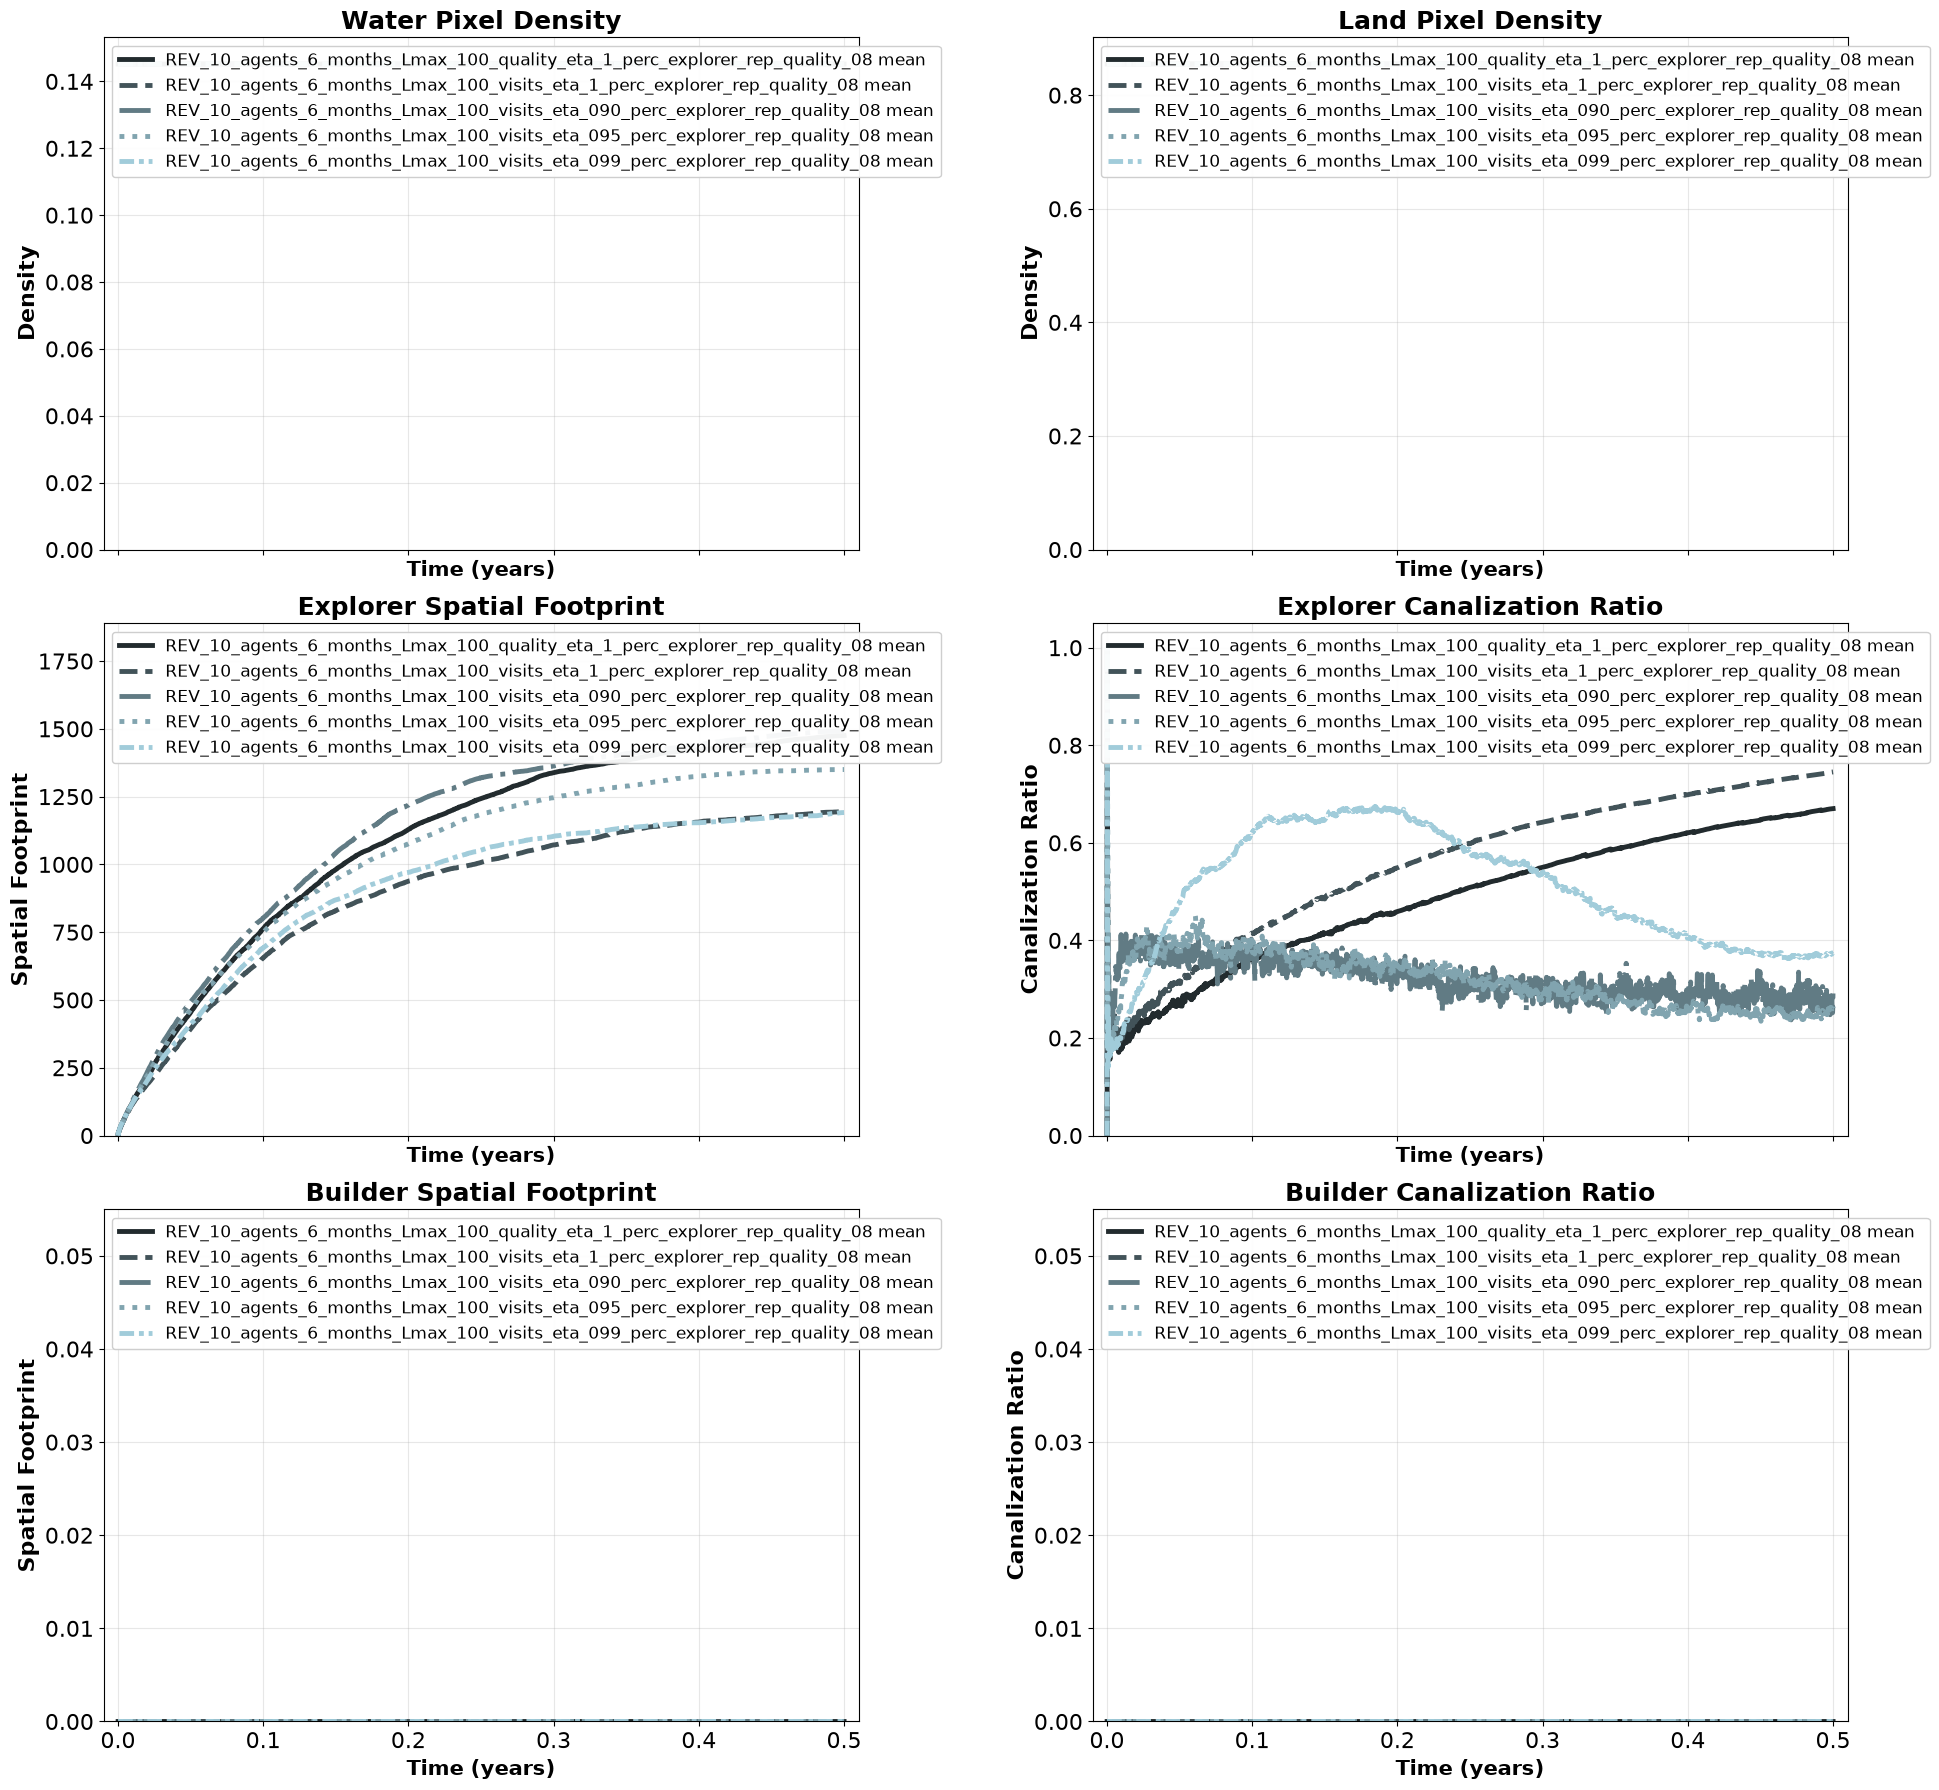

✓ Plot generated for 5 Monte Carlo simulation(s)


In [186]:
import numpy as np
import matplotlib.pyplot as plt
import beaversim.ral.backend.modules.module_colors as module_colors

# ============================================================================
# Compare multiple Monte Carlo simulations in six metric subplots (enhanced styling)
# ============================================================================
hours_per_year = 365 * 24  # 8760 hours per year
cmaps = module_colors.ColorMaps()

series_order = [
    ('water_pixel_density', 'Water Pixel Density'),
    ('land_pixel_density', 'Land Pixel Density'),
    ('explorer_spatial_footprint', 'Explorer Spatial Footprint'),
    ('explorer_canalization_ratio', 'Explorer Canalization Ratio'),
    ('builder_spatial_footprint', 'Builder Spatial Footprint'),
    ('builder_canalization_ratio', 'Builder Canalization Ratio'),
]

# Styling preferences: larger fonts, thicker mean lines, varied linestyles per simulation
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 16,
})

linestyles = ['solid', 'dashed', 'dashdot', 'dotted', (0, (3, 1, 1, 1)), (0, (1, 1))]

if not sim_results:
    raise ValueError("No simulations were loaded. Check the base_dirs list.")

n_sims = len(sim_results)
mean_colors = cmaps._water_colormap(np.linspace(0.2, 0.95, n_sims))

fig, axes = plt.subplots(3, 2, figsize=(20, 18), sharex=True)
axes = axes.flatten()

for ax, (key, title) in zip(axes, series_order):
    for sim_idx, (label, sim_data) in enumerate(sim_results.items()):
        all_stats = sim_data["all_stats"]
        arrays = all_stats.get(key, [])
        if not arrays:
            continue

        max_len = max([len(arr) for arr in arrays] + [0])
        padded = np.full((len(arrays), max_len), np.nan, dtype=float)
        for i, arr in enumerate(arrays):
            padded[i, :len(arr)] = arr

        mean_vals = np.nanmean(padded, axis=0)
        std_vals = np.nanstd(padded, axis=0)

        valid_idx = ~np.isnan(mean_vals)
        x = np.arange(1, np.sum(valid_idx) + 1) / hours_per_year
        mean_plot = mean_vals[valid_idx]
        std_plot = std_vals[valid_idx]

        style = linestyles[sim_idx % len(linestyles)]
        ax.plot(
            x,
            mean_plot,
            color=mean_colors[sim_idx],
            linestyle=style,
            linewidth=3.5,
            label=f"{label} mean",
        )
        ax.fill_between(
            x,
            mean_plot - std_plot,
            mean_plot + std_plot,
            color=mean_colors[sim_idx],
            alpha=0.0,
        )

    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("Time (years)", fontsize=15, fontweight="bold")
    if 'density' in key:
        ylabel = 'Density'
    elif 'footprint' in key:
        ylabel = 'Spatial Footprint'
    elif 'ratio' in key:
        ylabel = 'Canalization Ratio'
    else:
        ylabel = 'Value'
    ax.set_ylabel(ylabel, fontsize=16, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=16)
    ax.legend(loc='upper left', fontsize=12, framealpha=0.95)
    ax.margins(x=0.02)
    ax.set_ylim(bottom=0)

for empty_ax in axes[len(series_order):]:
    empty_ax.axis('off')

fig.tight_layout()
plt.show()

print(f"✓ Plot generated for {len(sim_results)} Monte Carlo simulation(s)")